In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [2]:
from src.io_tcga import load_tcga_expression_stub
from src.preprocess import basic_qc_filter, zscore

X, meta = load_tcga_expression_stub()
Xf = zscore(basic_qc_filter(X))
Xf.shape

/Users/dkim/Downloads/FROG-MOMI/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


(200, 8000)

In [3]:
# UMAP embedding + unsupervised clustering

from src.stratify import embed_umap, cluster_kmeans

/Users/dkim/Downloads/FROG-MOMI/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
emb = embed_umap(Xf)
emb.head()

/Users/dkim/Downloads/FROG-MOMI/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2
TCGA_0,10.501275,2.294258
TCGA_1,13.479051,2.524055
TCGA_2,12.260251,3.121763
TCGA_3,10.361311,3.502267
TCGA_4,11.238977,4.846128


In [5]:
clusters = cluster_kmeans(emb, k=3)
clusters.value_counts()

cluster
1    72
2    66
0    62
Name: count, dtype: int64

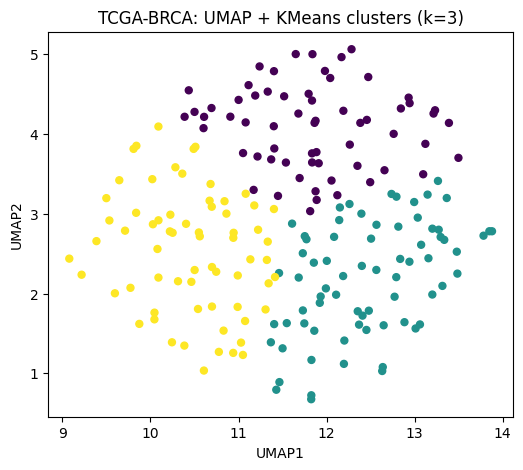

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(emb["UMAP1"], emb["UMAP2"], c=clusters, s=25)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("TCGA-BRCA: UMAP + KMeans clusters (k=3)")
plt.show()


In [7]:
meta.columns

Index(['vital_status'], dtype='object')

In [8]:
meta["label"] = (meta["vital_status"] == "Dead").astype(int)
meta["label"].value_counts()


label
1    106
0     94
Name: count, dtype: int64

In [9]:
import pandas as pd

df = pd.DataFrame({"cluster": clusters, "label": meta["label"]})
summary = df.groupby("cluster")["label"].agg(["count","sum","mean"]).rename(
    columns={"sum":"n_dead", "mean":"dead_rate"}
)
summary


,count,n_dead,dead_rate
cluster,,,
0,62,32,0.516129
1,72,36,0.500000
2,66,38,0.575758


In [10]:
import os
os.makedirs("data/processed", exist_ok=True)

Xf.to_pickle("data/processed/Xf.pkl")
meta.to_pickle("data/processed/meta.pkl")


In [11]:
import os
os.makedirs("data/processed", exist_ok=True)

clusters.to_pickle("data/processed/clusters.pkl")
